<a href="https://colab.research.google.com/github/hosseinayoubi/Report/blob/main/Patient_No_Show_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Patient Appointment No-Show Prediction
**Applied Analytics & AI Mini Project**

I kept this notebook fairly simple. The goal is to show the full path from raw appointment data to a model that can support a practical decision. I treat **No-show = Yes** as the positive class.

## 1. Load the data
I start with the original Kaggle CSV. The notebook checks a few common file locations so it also works after I move it into a GitHub project folder.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset directly from GitHub
DATA_URL = "https://raw.githubusercontent.com/hosseinayoubi/Report/main/Patient_No_Show-KaggleV2-May-2016.csv"

raw = pd.read_csv(DATA_URL)

print(f"Loaded {len(raw):,} rows from GitHub")
raw.head()

HTTPError: HTTP Error 404: Not Found

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Clean the data and create the target
Before modeling, I check the obvious data-quality issues: missing values, exact duplicate rows, impossible ages, and appointments that appear to happen before they were scheduled. I keep age 0 because it can represent infants.

In [ ]:
df = raw.copy()
df['ScheduledDay_dt'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay_dt'] = pd.to_datetime(df['AppointmentDay'])
df['waiting_days'] = (df['AppointmentDay_dt'].dt.normalize() - df['ScheduledDay_dt'].dt.normalize()).dt.days

quality = pd.Series({
    'rows': len(df),
    'missing values': int(df.isna().sum().sum()),
    'exact duplicate rows': int(df.duplicated().sum()),
    'age below 0': int((df['Age'] < 0).sum()),
    'negative waiting days': int((df['waiting_days'] < 0).sum())
})
quality

,0
rows,110527
missing values,0
exact duplicate rows,0
age below 0,1
negative waiting days,5


In [ ]:
clean = df[(df['Age'] >= 0) & (df['waiting_days'] >= 0)].copy()
clean['no_show'] = (clean['No-show'] == 'Yes').astype(int)
clean['appointment_weekday'] = clean['AppointmentDay_dt'].dt.day_name()
clean['scheduled_weekday'] = clean['ScheduledDay_dt'].dt.day_name()
clean['scheduled_hour'] = clean['ScheduledDay_dt'].dt.hour
clean['appointment_month'] = clean['AppointmentDay_dt'].dt.month

print(f'Rows after cleaning: {len(clean):,}')
print(f'Rows removed: {len(raw) - len(clean)}')

Rows after cleaning: 110,521
Rows removed: 6


## 3. Quick exploratory analysis
The target is imbalanced, so accuracy on its own can be misleading. I also look at waiting time because it is easy to interpret and useful for scheduling decisions.

In [ ]:
balance = clean['No-show'].value_counts().rename_axis('Outcome').to_frame('count')
balance['percent'] = (balance['count'] / len(clean) * 100).round(2)
balance

,count,percent
Outcome,,
No,88207,79.81
Yes,22314,20.19


In [ ]:
clean['waiting_group'] = pd.cut(
    clean['waiting_days'],
    bins=[-0.1, 0, 3, 7, 14, 30, 60, np.inf],
    labels=['Same day','1-3 days','4-7 days','8-14 days','15-30 days','31-60 days','61+ days']
)

waiting = clean.groupby('waiting_group', observed=False)['no_show'].agg(['count','mean'])
waiting['no_show_rate_percent'] = (waiting['mean'] * 100).round(2)
waiting

,count,mean,no_show_rate_percent
waiting_group,,,
Same day,38562,0.046471,4.65
1-3 days,14675,0.228893,22.89
4-7 days,17510,0.252027,25.20
8-14 days,12025,0.304699,30.47
15-30 days,17371,0.325888,32.59
31-60 days,8283,0.341543,34.15
61+ days,2095,0.284487,28.45


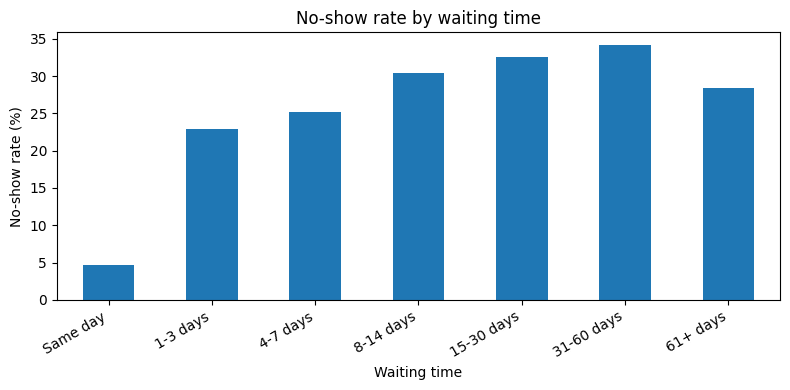

In [ ]:
ax = waiting['no_show_rate_percent'].plot(kind='bar', figsize=(8,4), title='No-show rate by waiting time')
ax.set_ylabel('No-show rate (%)')
ax.set_xlabel('Waiting time')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

The waiting-time pattern is clear in this dataset. Same-day appointments have a much lower no-show rate than appointments booked several weeks ahead. I treat this as an association, not proof that waiting time causes a patient to miss an appointment.

## 4. Build the models
I use a 70/30 split. I split by **PatientId**, not by individual row, so the same patient does not appear on both sides of the split. PatientId and AppointmentID are not model features.

I compare a simple majority-class baseline with three balanced classifiers. The class weighting is useful here because only about one appointment in five is a no-show.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

features = [
    'Gender','Age','Scholarship','Hipertension','Diabetes','Alcoholism','Handcap',
    'SMS_received','waiting_days','scheduled_hour','appointment_weekday',
    'scheduled_weekday','appointment_month'
]
X = clean[features]
y = clean['no_show']
groups = clean['PatientId']

split = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, test_idx = next(split.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f'Train rows: {len(X_train):,}')
print(f'Test rows:  {len(X_test):,}')

Train rows: 77,565
Test rows:  32,956


In [ ]:
numeric = ['Age','Scholarship','Hipertension','Diabetes','Alcoholism','Handcap','SMS_received','waiting_days','scheduled_hour','appointment_month']
categorical = ['Gender','appointment_weekday','scheduled_weekday']

prep = ColumnTransformer([
    ('num', Pipeline([
        ('fill', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ]), numeric),
    ('cat', Pipeline([
        ('fill', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical)
])

models = {
    'Dummy baseline': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear', random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, min_samples_leaf=100, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=120, max_depth=10, min_samples_leaf=50, class_weight='balanced_subsample', random_state=42, n_jobs=-1)
}

In [ ]:
results = []
fitted = {}

for name, model in models.items():
    pipe = Pipeline([('prep', prep), ('model', model)])
    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:, 1]
    cm = confusion_matrix(y_test, pred)

    results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'precision_no_show': precision_score(y_test, pred, zero_division=0),
        'recall_no_show': recall_score(y_test, pred, zero_division=0),
        'f1_no_show': f1_score(y_test, pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, prob),
        'tn': cm[0,0], 'fp': cm[0,1], 'fn': cm[1,0], 'tp': cm[1,1]
    })
    fitted[name] = (pipe, pred, prob)

metrics = pd.DataFrame(results)
metrics.round(4)

,model,accuracy,precision_no_show,recall_no_show,f1_no_show,roc_auc,tn,fp,fn,tp
0,Dummy baseline,0.7956,0.0000,0.0000,0.0000,0.5000,26221,0,6735,0
1,Logistic Regression,0.6632,0.3195,0.5739,0.4105,0.6689,17990,8231,2870,3865
2,Decision Tree,0.5733,0.3027,0.8347,0.4443,0.7246,13271,12950,1113,5622
3,Random Forest,0.5733,0.3042,0.8451,0.4474,0.7284,13201,13020,1043,5692


The dummy baseline gets high accuracy because it predicts the majority class every time. It completely misses the no-show class. That is why I focus on recall, F1, and ROC-AUC instead of accuracy alone.

The Random Forest gives the best F1 score for no-shows in this run. Its recall is high, but precision is much lower. In practice, that means it catches many no-shows but also flags many patients who will actually attend.

In [ ]:
best_name = metrics.loc[metrics['f1_no_show'].idxmax(), 'model']
best_pipe, best_pred, best_prob = fitted[best_name]
print('Best model by no-show F1:', best_name)
print(confusion_matrix(y_test, best_pred))

Best model by no-show F1: Random Forest
[[13201 13020]
 [ 1043  5692]]


## 5. What is driving the Random Forest?
Feature importance does not prove causation, but it gives a useful sense of what the model relies on.

In [ ]:
rf_pipe = fitted['Random Forest'][0]
feature_names = rf_pipe.named_steps['prep'].get_feature_names_out()
importance = rf_pipe.named_steps['model'].feature_importances_

feature_importance = pd.DataFrame({'feature': feature_names, 'importance': importance})
feature_importance = feature_importance.sort_values('importance', ascending=False).head(10)
feature_importance

,feature,importance
7,num__waiting_days,0.692815
0,num__Age,0.079240
6,num__SMS_received,0.064756
8,num__scheduled_hour,0.037186
22,cat__scheduled_weekday_Tuesday,0.011485
18,cat__scheduled_weekday_Friday,0.011168
23,cat__scheduled_weekday_Wednesday,0.010753
2,num__Hipertension,0.010037
13,cat__appointment_weekday_Monday,0.009755
9,num__appointment_month,0.009514


## 6. Threshold check
A prediction model does not have to use 0.50 as the cut-off. A lower threshold catches more potential no-shows but also creates more false alarms. I compare a few thresholds so the trade-off is visible.

In [ ]:
threshold_rows = []
for threshold in [0.30, 0.40, 0.50, 0.60]:
    pred_t = (best_prob >= threshold).astype(int)
    threshold_rows.append({
        'threshold': threshold,
        'precision': precision_score(y_test, pred_t, zero_division=0),
        'recall': recall_score(y_test, pred_t, zero_division=0),
        'f1': f1_score(y_test, pred_t, zero_division=0),
        'flagged_percent': pred_t.mean() * 100
    })

pd.DataFrame(threshold_rows).round(3)

,threshold,precision,recall,f1,flagged_percent
0,0.3,0.287,0.932,0.439,66.249
1,0.4,0.288,0.921,0.439,65.272
2,0.5,0.304,0.845,0.447,56.779
3,0.6,0.353,0.521,0.421,30.216


## 7. Responsible use
I would use this model only for low-risk support, such as prioritizing reminders or offering easier rescheduling. I would not use it to cancel appointments, reduce access, or automatically penalize a patient.

There are also fairness and privacy issues. Age, location, and other variables can reflect social differences. A real deployment would need subgroup monitoring, clear access controls, and human review. I excluded `Neighbourhood` from the final model for this reason.

**AI use note:** I used AI tools for coding support and language editing. I reviewed the workflow, reran the notebook, and checked the values reported in the project files against the notebook output.

## 8. Short takeaway
The strongest practical signal was waiting time. The final Random Forest catches a large share of actual no-shows, but its precision is limited. That makes it more suitable for supportive actions, such as reminders, than for automatic decisions.